# ÉquiAlgo : rapport d'audit et de correction du biais régional

Ce carnet suit l'ordre de la grille : (a) **diagnostic** du biais et variables proxys, (b) **définition de l'équité** et justification des métriques, (c) chaîne de correction et décision publiée, (d) garde-fous, (e) **front de Pareto** (balayage de la contrainte d'équité de la chaîne déclarée), (f) pistes rejetées avec leurs preuves, (g) limites.

Les calculs appellent les fonctions du dépôt (`src.policy`, `src.monitoring`, `src.evaluation`) ; rien n'y est réimplémenté. Les chiffres de la décision publiée sont lus dans `decision_record.json` ; ceux du front de Pareto dans `resultats_pareto_declare.csv` et `resultats_pareto.csv` (écrits par `model_corrige.py`). Tout vient de l'historique des 10 000 demandes : aucun score externe n'entre dans la chaîne. Données synthétiques, graines fixes.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, time
T0 = time.time()
import numpy as np, pandas as pd
from IPython.display import Image, display
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from src.policy import (CommitteeModel, DECLARED_HOURS_WEIGHT, DECLARED_INCOME_WEIGHT, REVIEWER_INCOME_WEIGHTS, auc,
                        budget_share, correction_report, is_remote, reference_weights)
from src.policy.schema import COMMITTEE_FEATURES, committee_features
from src.monitoring.checks import proxy_auc

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30); pd.set_option('display.max_colwidth', 90)
history = pd.read_csv('data/donnees_demandes.csv')
batch = pd.read_csv('data/candidats_evaluation.csv')
record = json.load(open('decision_record.json'))
y = history['decision_octroi'].to_numpy()
remote = is_remote(history)
share = budget_share(history)
print(f"{len(history):,} dossiers historiques, {remote.sum():,} en région éloignée ; part historique d'octrois {share:.2%}")

10,000 dossiers historiques, 4,000 en région éloignée ; part historique d'octrois 39.94%


## (a) Diagnostic : le comité applique une pénalité régionale plate

Le modèle du comité (régression logistique sur 8 critères légitimes + indicateur « région éloignée ») sert **au diagnostic** : il estime la pénalité, son intervalle de confiance par rééchantillonnage (200 tirages) et teste si les régions suivent des règles différentes (test du rapport de vraisemblance sur les pentes).

In [2]:
report = correction_report(history, share)
rates = pd.Series(y).groupby(remote).mean()
print(f"Taux historique d'octroi : centre {rates[0]:.1%}, éloigné {rates[1]:.1%} (écart {rates[0] - rates[1]:.1%})")
print(f"Pénalité régionale : {report.penalty:.2f} logit, IC 95 % [{report.penalty_ci[0]:.2f} ; {report.penalty_ci[1]:.2f}] (rapport de cotes x {np.exp(report.penalty):.2f})")
print(f"Test des mêmes pentes : khi² = {report.slope_test_statistic:.2f}, ddl = {report.slope_test_df}, p = {report.slope_test_p:.2f}"
      "  -> p élevé : une pénalité plate, pas des règles différentes par région")

Taux historique d'octroi : centre 48.4%, éloigné 27.3% (écart 21.1%)
Pénalité régionale : -1.90 logit, IC 95 % [-2.07 ; -1.73] (rapport de cotes x 0.15)
Test des mêmes pentes : khi² = 4.38, ddl = 8, p = 0.82  -> p élevé : une pénalité plate, pas des règles différentes par région


### Même cote R, issue différente

À cote R égale, le comité accorde beaucoup moins aux candidats éloignés : l'écart de cote R moyen (0,7 point) n'explique pas l'écart de 21 points.

In [3]:
rows = []
for low, high in [(26, 28), (28, 30), (30, 32)]:
    band = history[(history['cote_r_equivalent'] > low) & (history['cote_r_equivalent'] <= high)]
    grp = band.groupby(is_remote(band))['decision_octroi'].agg(['mean', 'size'])
    rows.append({'cote R': f"]{low} ; {high}]", "octrois centre": f"{grp.loc[0, 'mean']:.1%}", "octrois éloigné": f"{grp.loc[1, 'mean']:.1%}",
                 'dossiers centre / éloigné': f"{grp.loc[0, 'size']} / {grp.loc[1, 'size']}"})
print(pd.DataFrame(rows).to_string(index=False))

   cote R octrois centre octrois éloigné dossiers centre / éloigné
]26 ; 28]          24.1%            6.7%               1496 / 1063
]28 ; 30]          70.9%           40.8%                1438 / 910
]30 ; 32]          95.8%           83.1%                 986 / 514


### Variables proxys de la région

Pouvoir de chaque variable pour prédire « région éloignée » (AUC, 0,5 = aucun, 1 = parfait). Le code postal est encodé par son taux éloigné sur une moitié de l'échantillon et évalué sur l'autre. La dernière colonne dit si la variable entre dans notre score, et pourquoi.

In [4]:
half = np.random.default_rng(0).random(len(history)) < 0.5
postal_rate = pd.Series(remote[half]).groupby(history['code_postal_3'][half].to_numpy()).mean()
postal_score = history['code_postal_3'][~half].map(postal_rate).fillna(0.5).to_numpy()
columns = {'code postal (3 car.)': None, 'distance au campus': 'distance_domicile_campus_km',
           'heures de travail': 'heures_travail_semaine', 'revenu familial': 'revenu_familial_estime',
           'première génération': 'premiere_generation_universitaire', 'cote R': 'cote_r_equivalent'}
usage = {'code postal (3 car.)': 'non : encode la région presque parfaitement',
         'distance au campus': 'non : encode la région, aucun examinateur ne la retient',
         'heures de travail': 'oui : crédit linéaire déclaré (signe + fixé par les examinateurs)',
         'revenu familial': 'oui, minime (+0,025) : pénalité régionale cachée chez le comité, coût mesuré par la garde forte',
         'première génération': 'non : poids 0 pour les cinq examinateurs',
         'cote R': 'oui : critère principal'}
rows = {}
for label, column in columns.items():
    score = postal_score if column is None else history[column].to_numpy()
    truth = remote[~half] if column is None else remote
    a = auc(truth, score)
    rows[label] = max(a, 1 - a)
proxies = pd.DataFrame({'AUC région': pd.Series(rows).round(3), 'dans notre score ?': pd.Series(usage)}).sort_values('AUC région', ascending=False)
print(proxies.to_string())
print(f"\nAUC (validation croisée) d'un modèle sur les trois variables du score (cote R, revenu, heures) : {proxy_auc(history):.3f}")

                      AUC région                                                                               dans notre score ?
code postal (3 car.)       1.000                                                      non : encode la région presque parfaitement
distance au campus         0.998                                          non : encode la région, aucun examinateur ne la retient
heures de travail          0.805                                oui : crédit linéaire déclaré (signe + fixé par les examinateurs)
revenu familial            0.693  oui, minime (+0,025) : pénalité régionale cachée chez le comité, coût mesuré par la garde forte
première génération        0.590                                                         non : poids 0 pour les cinq examinateurs
cote R                     0.561                                                                          oui : critère principal

AUC (validation croisée) d'un modèle sur les trois variables du score (cote R, revenu, he

Retirer la colonne région ne suffit donc pas (la consigne le mesure : écart de parité 0,188 → 0,181) : code postal et distance l'encodent presque parfaitement ; les heures et le revenu en portent une grande part. Nous n'utilisons ni code postal ni distance ; heures et revenu n'entrent qu'avec des poids déclarés et des signes fixés par des humains.

### Le revenu : une pénalité régionale cachée ; les chemins causaux se compensent

Sur l'échelle du comité (logit), on mesure la contribution moyenne de chaque critère à l'écart éloigné − centre (coefficient × décalage moyen standardisé), et on la compare à la pénalité explicite.

In [5]:
committee = CommitteeModel().fit(history, y)
Z = committee.scaler_.transform(committee_features(history))
coef = dict(zip(COMMITTEE_FEATURES, committee.lr_.coef_[0][:-1]))
shift = {name: Z[remote == 1, i].mean() - Z[remote == 0, i].mean() for i, name in enumerate(COMMITTEE_FEATURES)}
penalty = abs(committee.remote_penalty_)
table = pd.DataFrame({'décalage éloigné − centre (écarts-types)': shift, 'contribution (logit)': {n: coef[n] * shift[n] for n in coef}})
table['part de la pénalité explicite'] = table['contribution (logit)'] / penalty
print(table.loc[['cote_r', 'heures_travail', 'log_revenu']].round(3).to_string())
contrib = table['contribution (logit)']
print(f"\nPénalité explicite : {committee.remote_penalty_:.2f} logit.")
print(f"Revenu : {contrib['log_revenu']:+.2f} logit aux candidats éloignés = {abs(contrib['log_revenu']) / penalty:.0%} de la pénalité explicite (pénalité cachée).")
print(f"Chemins légitimes : heures {contrib['heures_travail']:+.2f} contre cote R {contrib['cote_r']:+.2f} logit -> net {contrib['heures_travail'] + contrib['cote_r']:+.2f} : ils se compensent presque.")
print(f"Pénalité totale subie (explicite + revenu) : {committee.remote_penalty_ + contrib['log_revenu']:+.2f} logit.")

                décalage éloigné − centre (écarts-types)  contribution (logit)  part de la pénalité explicite
cote_r                                            -0.220                -0.905                         -0.476
heures_travail                                     1.064                 0.804                          0.423
log_revenu                                        -0.681                -0.543                         -0.286

Pénalité explicite : -1.90 logit.
Revenu : -0.54 logit aux candidats éloignés = 29% de la pénalité explicite (pénalité cachée).
Chemins légitimes : heures +0.80 contre cote R -0.90 logit -> net -0.10 : ils se compensent presque.
Pénalité totale subie (explicite + revenu) : -2.44 logit.


Lecture : une fois la pénalité explicite retirée, ce qui reste d'écart légitime vient de la cote R (plus basse en région) et du crédit d'heures (plus élevées en région), deux effets de signes opposés et de même ordre. C'est pourquoi la décision corrigée a des taux proches entre régions **sans aucun quota** : la parité y est une conséquence, pas une contrainte.

### Reconstitution du générateur

Trois constats sur l'historique décrivent le mécanisme qui a produit les décisions : (1) **deux groupes** : les cinq régions se réduisent à centre / éloigné (pénalité par région ci-dessous) ; (2) **indépendance à l'intérieur des groupes** : les critères sont pratiquement non corrélés une fois le groupe fixé, donc les proxys n'encodent la région que par le décalage des moyennes ; (3) **comité linéaire** : mêmes pentes dans les deux groupes (test ci-dessus) et aucun modèle plus riche ne bat la régression logistique en validation croisée (section f).

In [6]:
X = StandardScaler().fit_transform(committee_features(history))
others = ['Capitale-Nationale', 'Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']
D = np.column_stack([(history['region_administrative'] == r).astype(float) for r in others])
per_region = LogisticRegression(max_iter=3000).fit(np.hstack([X, D]), y).coef_[0][-4:]
print("Terme régional du comité par région (logit, référence Montréal) :")
print(pd.Series(per_region, index=others).round(2).to_string())
numeric = history[['cote_r_equivalent', 'heures_travail_semaine', 'revenu_familial_estime', 'distance_domicile_campus_km',
                   'premiere_generation_universitaire']].assign(revenu_familial_estime=lambda d: np.log(d['revenu_familial_estime']))
for group, label in [(0, 'centre'), (1, 'éloigné')]:
    corr = numeric[remote == group].corr().to_numpy()
    print(f"Corrélation maximale entre critères dans le groupe {label} : {np.abs(corr[np.triu_indices(len(corr), 1)]).max():.3f}")
print("Moyennes par groupe :")
print(numeric.groupby(np.where(remote == 1, 'éloigné', 'centre')).mean().round(2).to_string())

Terme régional du comité par région (logit, référence Montréal) :
Capitale-Nationale              -0.03
Bas-Saint-Laurent               -1.91
Cote-Nord                       -1.92
Gaspesie-Iles-de-la-Madeleine   -1.81
Corrélation maximale entre critères dans le groupe centre : 0.014
Corrélation maximale entre critères dans le groupe éloigné : 0.030
Moyennes par groupe :
         cote_r_equivalent  heures_travail_semaine  revenu_familial_estime  distance_domicile_campus_km  premiere_generation_universitaire
centre               27.99                    8.97                   11.15                        19.79                               0.26
éloigné              27.33                   13.02                   10.84                       221.45                               0.44


## (b) Définition de l'équité et justification des métriques

**Choix : égalité des chances (equal opportunity), pas parité démographique.** Les deux ne peuvent tenir ensemble quand les groupes ont des profils différents. Nous retenons l'égalité des chances parce que :

1. **La cote R diffère légitimement entre les groupes** (27,3 contre 28,0). Un tri au seul mérite donne déjà centre 42,8 % / éloigné 35,8 % sur les candidats : forcer la parité refuserait des candidats plus méritants pour égaliser des taux, ce que quatre examinateurs sur cinq signalent comme un « drapeau rouge » (quotas, parité forcée).
2. **Le tort constaté est une pénalité à mérite égal** (−1,90 logit, même R, issue différente) : c'est exactement ce que mesure l'égalité des chances (taux d'octroi parmi les candidats méritants, centre contre éloigné).
3. **C'est la métrique de la grille** (part de l'écart d'égalité des chances de 0,270 refermée).
4. La parité reste **surveillée** comme indicateur secondaire (alerte > 0,08), avec le ratio d'impact par région et les écarts intersectionnels.

**Qui est « méritant » ? Consensus de cinq examinateurs.** Faute de l'étalon caché, cinq examinateurs indépendants (mérite, besoin, juridique, processus de données, équité régionale ; `docs/reviews/`) ont chacun proposé une règle de référence ; `docs/reviews/CONSENSUS.md` les agrège (signe à la majorité, poids médian). Consensus : cote R d'abord, heures en petit crédit linéaire, première génération 0, aucune variable géographique.

**Les signes viennent des humains, les amplitudes des données.** Les examinateurs fixent les **signes** de légitimité (R +, heures +, première génération 0). L'**amplitude** des heures est tirée des données : le rapport heures / R de l'ajustement du comité (0,1835, recalculé à chaque exécution) ; nous déclarons 0,185, retenu par essais, à 0,0015 de ce rapport. Le revenu est le seul désaccord (mérite, juridique, régional 0 ; besoin −0,05 ; processus de données +0,19) : le poids retenu, **+0,025**, est un choix de modélisation déclaré dans cette plage, et son coût en équité est plafonné par la garde forte (≤ 5 % de la pénalité retirée).

| Métrique | Définition | Pourquoi |
|---|---|---|
| Écart EO signé vs mérite | TPR centre − TPR éloigné, méritants = meilleurs R au même budget | métrique principale ; signée car le crédit d'heures sert légitimement un peu plus les régions (plage admise −0,09 à +0,05) |
| Écart EO moyen vs les 5 références | moyenne des écarts EO contre chaque règle d'examinateur | robustesse à l'incertitude sur l'étalon caché |
| Accord moyen avec les 5 références | part de décisions identiques | utilité : substitut de la concordance avec l'étalon |
| Parité, ratio d'impact par région, intersectionnel | taux par groupe et sous-groupe | surveillance secondaire : détecter une sur-correction ou un sous-groupe lésé |

In [7]:
weights = pd.DataFrame(reference_weights(committee)).loc[['cote_r', 'heures_travail', 'log_revenu', 'premiere_generation']]
print("Poids des règles de référence (R = 1, unités standardisées) :")
print(weights.round(4).to_string())
print(f"\nPoids déclaré des heures : {DECLARED_HOURS_WEIGHT} ; rapport heures / R du comité (données) : {committee.hours_over_r():.4f}")
print(f"Poids déclaré du revenu : {DECLARED_INCOME_WEIGHT} ; plage des examinateurs : {min(REVIEWER_INCOME_WEIGHTS.values())} à {max(REVIEWER_INCOME_WEIGHTS.values())}")

Poids des règles de référence (R = 1, unités standardisées) :
                     consensus   merit    need   legal  data_process  regional
cote_r                   1.000  1.0000  1.0000  1.0000        1.0000    1.0000
heures_travail           0.185  0.1835  0.1835  0.1835        0.1835    0.1835
log_revenu               0.025  0.0000 -0.0500  0.0000        0.1900    0.0000
premiere_generation      0.000  0.0000  0.0000  0.0000        0.0000    0.0000

Poids déclaré des heures : 0.185 ; rapport heures / R du comité (données) : 0.1835
Poids déclaré du revenu : 0.025 ; plage des examinateurs : -0.05 à 0.19


## (c) Chaîne de correction et décision publiée

```
historique (10 000) -> validation -> modèle du comité (diagnostic : pénalité, IC, rapport heures / R)
   -> base = règle de consensus : z(R) + 0,185 x z(heures) + 0,025 x z(log revenu)   (unités de cote R, sans région)
   -> + 2,5 x résidu : ensemble de 4 réseaux TabM bornés (entrées R et heures), appris sur l'historique,
        artefact vérifié par SHA-256 (models/tabm_residual_ensemble_rh/)
   -> les k meilleurs candidats (k = part historique x n = 1 598)
   -> jury (panel des cinq règles) et raisonnement en MODE AUDIT : votes, traces, contradictions enregistrés, aucun échange
   -> quatre garde-fous : surveillance + garde du jury + garde du consensus + garde forte
   -> au plus un décalage borné (|d| <= 0,10) ou BLOCAGE -> garde de sortie -> PUBLICATION ou BLOCAGE
```

In [8]:
regions = ['Montreal', 'Capitale-Nationale', 'Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']
monitoring = {c['name']: c for c in record['verdicts'][0]['checks']}
print(f"Statut : {record['status']} ; octrois {record['grants']:,} sur {record['applicants']:,} ({record['grants'] / record['applicants']:.2%}) ; décalage {record['offset']:+.3f}")
print(f"Configuration : {record['config']['name']} ; mélange du résidu {record['config']['residual_blend']} ; artefact {record['config']['residual_artefact']}")
print("Taux par région : " + ', '.join(f"{r} {record['region_rates'][r]:.1%}" for r in regions))
jury, delib = record['jury'], record['deliberation']
print(f"Jury (mode audit) : {jury['triggered']} cas examinés, {jury['overturned_out']} échanges contestés, appliqué : {jury['applied']}")
print(f"Raisonnement (mode audit) : {delib['examined']} examinés, {delib['proposed_moves']} déplacements proposés, {delib['contradicted_kept']} contradictions conservées, {delib['moved_in'] + delib['moved_out']} appliqué")
for name in ['demographic parity gap (centre vs remote)', 'impact ratio, lowest/highest region', 'opportunity gap vs merit reference',
             'opportunity gap vs corrected committee']:
    c = monitoring[name]; print(f"  {name}: {c['value']:+.4f}  [{c['status']}]  {c['detail']}")

Statut : published ; octrois 1,598 sur 4,000 (39.95%) ; décalage +0.000
Configuration : declared: base + TabM ensemble residual ; mélange du résidu 2.5 ; artefact tabm_residual_ensemble_rh
Taux par région : Montreal 40.4%, Capitale-Nationale 39.7%, Bas-Saint-Laurent 38.1%, Cote-Nord 39.3%, Gaspesie-Iles-de-la-Madeleine 41.2%
Jury (mode audit) : 200 cas examinés, 26 échanges contestés, appliqué : False
Raisonnement (mode audit) : 200 examinés, 6 déplacements proposés, 49 contradictions conservées, 0 appliqué
  demographic parity gap (centre vs remote): +0.0045  [OK]  centre 40.1%, remote 39.7%
  impact ratio, lowest/highest region: +0.9239  [OK]  Bas-Saint-Laurent 38.1% vs Gaspesie-Iles-de-la-Madeleine 41.2%
  opportunity gap vs merit reference: -0.0605  [OK]  deserving = top R scores at the same budget; centre minus remote -0.0605, absolute 0.0605
  opportunity gap vs corrected committee: +0.0527  [WARN]  deserving = committee rule without regional penalty


## (d) Garde-fous

1. **Surveillance** : budget, parité, ratio d'impact, écart d'opportunité **signé** contre le mérite (plage −0,09 à +0,05), écart contre le comité corrigé, intersections, dérive (PSI, AUC des proxys).
2. **Garde du jury** : effet d'équité des échanges appliqués, volume, accord des jurés ; une ALERTE retire le jury (`REVERT_JURY`).
3. **Garde du consensus** : bandes de taux et limites issues des cinq examinateurs ; une ALERTE non corrigible bloque.
4. **Garde forte** : la décision doit rester au moins aussi équitable que la règle de consensus déclarée (ratio d'impact, sous-groupes, mérite sur cinq régions, écart à chaque référence, coût du revenu).

Plan de surveillance en production : `docs/MONITORING_PLAN.md`.

In [9]:
def guard_table(checks):
    return pd.DataFrame([{'contrôle': c['name'], 'valeur': round(c['value'], 4), 'seuil': c['threshold'], 'statut': c['status']} for c in checks])

pd.set_option('display.max_colwidth', 70)
layers = [('1. Surveillance', record['verdicts'][0]), ('2. Garde du jury', record['jury_guard']),
          ('3. Garde du consensus', record['consensus_guard']), ('4. Garde forte', record['strong_guard'])]
for title, layer in layers:
    print(f"\n{title} : statut global {layer['status']}")
    print(guard_table(layer['checks']).to_string(index=False))


1. Surveillance : statut global WARN
                                       contrôle  valeur                                                seuil statut
                       grant rate within budget  0.3995                                              36%-44%     OK
      demographic parity gap (centre vs remote)  0.0045                                           warn > 0.1     OK
            impact ratio, lowest/highest region  0.9239                                           warn < 0.8     OK
             opportunity gap vs merit reference -0.0605 ok in [-0.0882, 0.0378], alert outside [-0.09, 0.05]     OK
         opportunity gap vs corrected committee  0.0527                                          warn > 0.03   WARN
  largest intersectional gap (centre vs remote)  0.0176                                          warn > 0.15     OK
proxy drift: region predictability (AUC change)  0.0081                                        alert > +0.05     OK
                         feature d

## (e) Front de Pareto : balayage de la contrainte d'équité de la chaîne déclarée

**Contrainte balayée** : la part λ de la pénalité régionale du comité retirée du score déclaré, de 0 (pénalité du comité conservée) à 1 (réglage déclaré). Score(λ) = base + 2,5 × résidu + (1 − λ) × pénalité × éloigné, la pénalité étant convertie en unités de cote R (−1,90 logit / coefficient de R). Deux autres réglages de la chaîne sont balayés à λ = 1 : le **mélange du résidu** TabM (0 à 5) et le **poids du revenu** (−0,05 à +0,19, la plage des examinateurs). Chaque point garde le même budget (1 598 octrois sur les 4 000 candidats). Axes : écart d'égalité des chances moyen contre les cinq références (↓) et accord moyen avec elles (↑) ; les références sont construites sur l'historique.

Le résidu TabM n'existe que pour les 4 000 candidats : ce balayage complet se fait donc sur eux. Le même balayage de λ sur la base déclarée (sans résidu) est répété sur 10 partitions 70/30 de l'historique, avec les autres méthodes (ExpGrad, ThresholdOptimizer, retrait de proxys) dans le graphique de comparaison plus bas.

                                  method  rate_centre  rate_remote  eo_gap_reviewers_mean  agree_reviewers_mean  g_merit  dp_gap  pareto
forêt aléatoire de production, au budget       0.4777       0.2856                 0.2673                0.9035   0.2024  0.1920   False
                              retrait 0%       0.4642       0.3053                 0.2233                0.9247   0.1430  0.1589   False
                             retrait 10%       0.4599       0.3114                 0.2075                0.9293   0.1308  0.1485   False
                             retrait 20%       0.4540       0.3200                 0.1853                0.9356   0.1141  0.1340   False
                             retrait 30%       0.4465       0.3311                 0.1575                0.9431   0.0805  0.1154   False
                             retrait 40%       0.4393       0.3415                 0.1299                0.9508   0.0557  0.0978   False
                             retrait 50% 

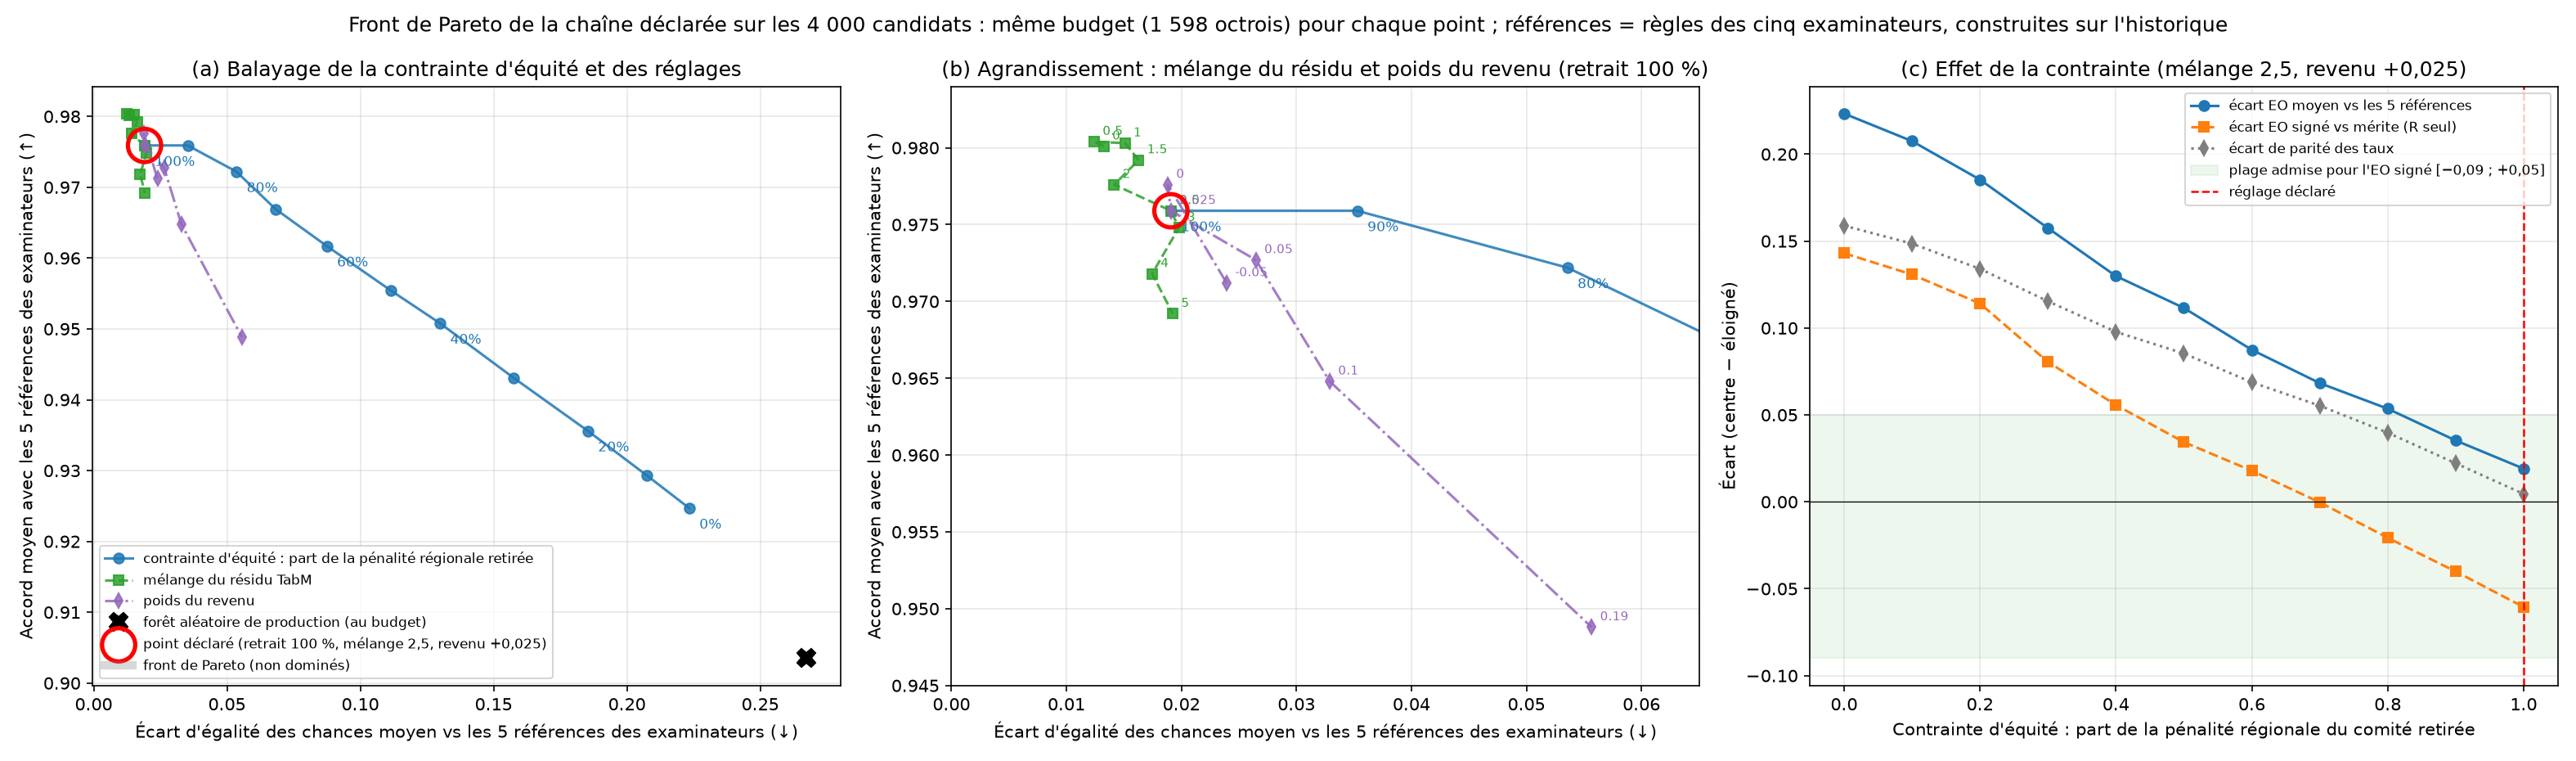

In [10]:
sweep = pd.read_csv('resultats_pareto_declare.csv')
cols = ['method', 'rate_centre', 'rate_remote', 'eo_gap_reviewers_mean', 'agree_reviewers_mean', 'g_merit', 'dp_gap', 'pareto']
print(sweep[cols].round(4).to_string(index=False))
anchor = sweep[sweep.method.str.startswith('forêt')].iloc[0]
declared = sweep[sweep.method == 'déclaré'].iloc[0]
closed = 1 - declared.eo_gap_reviewers_mean / anchor.eo_gap_reviewers_mean
print(f"\nModèle de production au budget : écart EO moyen {anchor.eo_gap_reviewers_mean:.3f} ; point déclaré : {declared.eo_gap_reviewers_mean:.3f} "
      f"-> {closed:.0%} de l'écart refermé (contre nos références, pas l'étalon caché)")
display(Image('pareto_front.png'))

**Lecture.**
- **La contrainte d'équité domine le front** (a, c) : chaque pas de λ réduit l'écart EO et *augmente* l'accord avec les références ; il n'y a pas d'arbitrage équité / utilité contre ces références, parce que la pénalité retirée n'est justifiée par aucun critère légitime. À λ = 1, l'écart EO signé vs mérite vaut −0,060 (dans la plage admise) et la parité 0,005, sans quota.
- **Mélange du résidu et poids du revenu** (b) ne déplacent le point que d'environ ±0,01 en écart EO et en accord. Le résidu 2,5 n'est **pas** sur le front calculé contre ces références : celles-ci sont des règles linéaires de même forme que la base, donc tout résidu non linéaire s'en écarte par construction. Le mélange déclaré est justifié par la perte logarithmique hors échantillon sur les vraies décisions historiques (`models/tabm_residual_ensemble_rh/manifest.json`), pas par ce graphique ; l'écart au front (environ 0,007 en EO et 0,005 en accord) est le coût que nous acceptons et déclarons.
- Revenu > +0,05 : l'écart EO moyen et l'accord se dégradent nettement (pénalité régionale cachée réintroduite) ; +0,19 (processus de données) coûte 0,037 d'écart EO et 0,027 d'accord.
- Le point déclaré du graphique est **identique, décision par décision, à `predictions.csv`** (vérifié par `model_corrige.py`).

Comparaison sur 10 partitions 70/30 de l'historique (moyennes) :
                                    method  rate_centre  rate_remote  eo_gap_reviewers_mean  agree_reviewers_mean  g_merit  eo_gap_corrected  acc_historical  pareto
 production RF, natural threshold (anchor)        0.458        0.265                  0.316                 0.909    0.247             0.253           0.878   False
                   production RF at budget        0.474        0.287                  0.266                 0.911    0.188             0.211           0.876   False
                         drop proxies only        0.443        0.333                  0.142                 0.921    0.059             0.089           0.875   False
          ThresholdOptimizer, natural rate        0.512        0.334                  0.171                 0.895    0.104             0.104           0.876   False
                          ExpGrad eps=0.05        0.445        0.331                  0.160                 0.

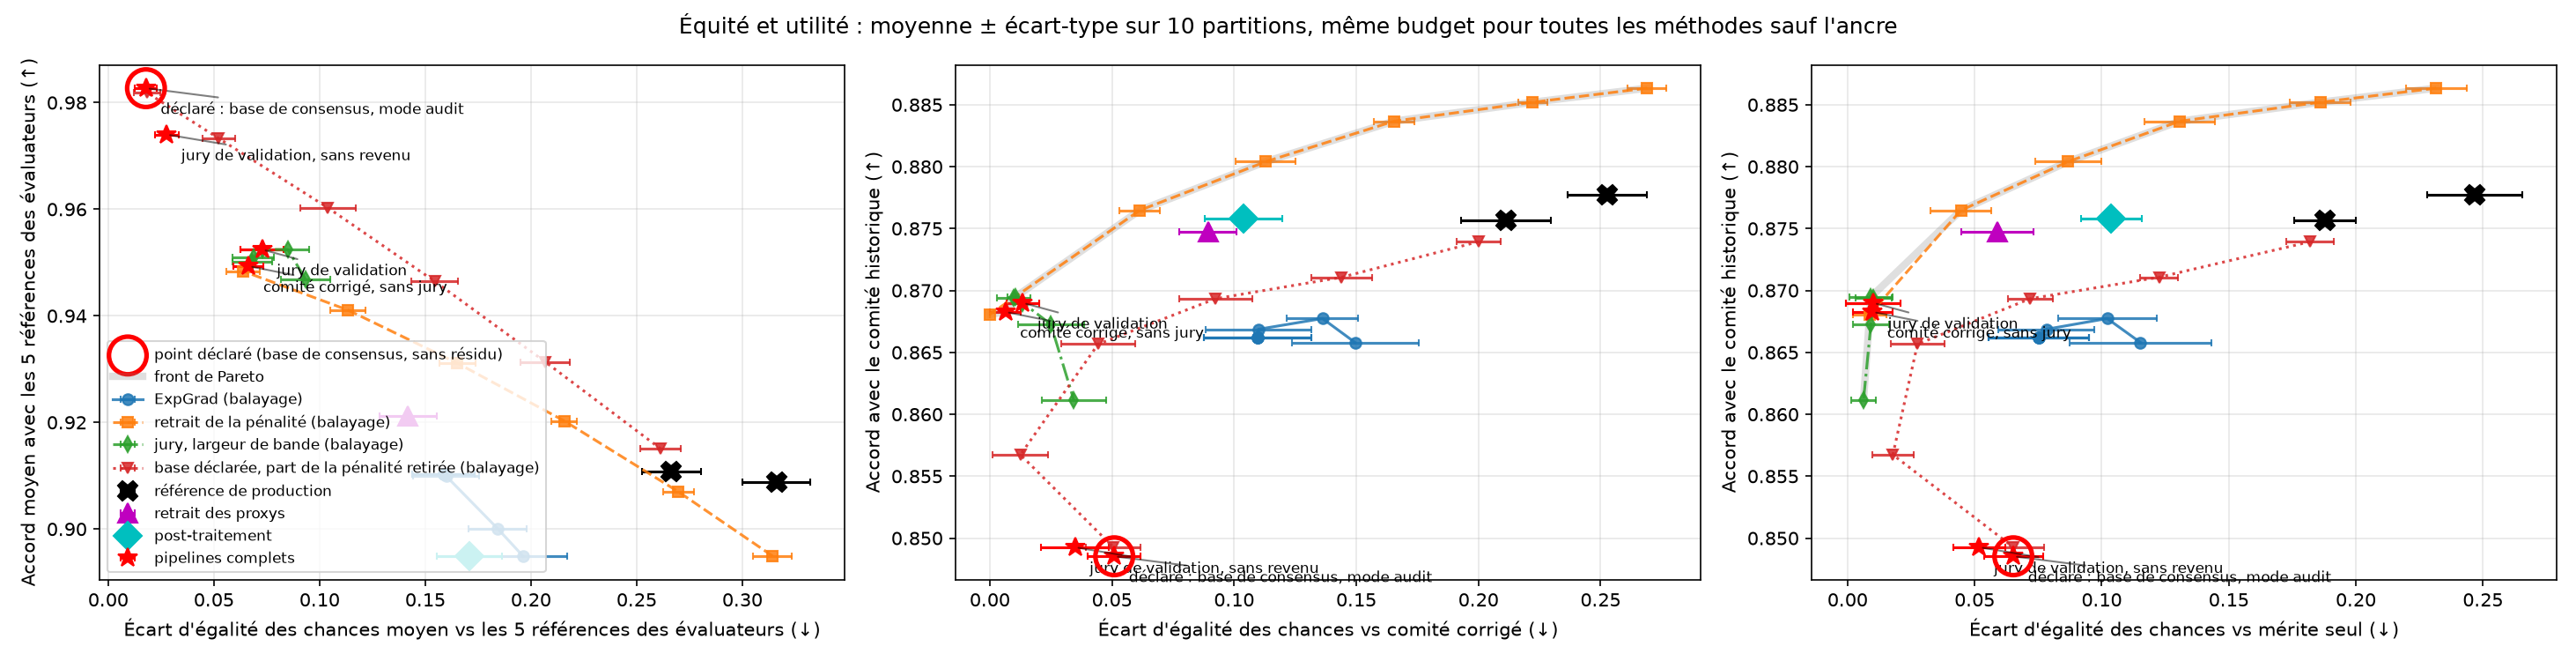

In [11]:
pareto = pd.read_csv('resultats_pareto.csv')
cols = ['method', 'rate_centre', 'rate_remote', 'eo_gap_reviewers_mean', 'agree_reviewers_mean', 'g_merit',
        'eo_gap_corrected', 'acc_historical', 'pareto']
key = pareto.family.isin(['declared base removal sweep', 'baseline', 'post-processing']) | pareto.method.isin(
    ['declared base: consensus panel, audit mode', 'committee-corrected, no jury', 'ExpGrad eps=0.05', 'drop proxies only'])
print("Comparaison sur 10 partitions 70/30 de l'historique (moyennes) :")
print(pareto[key][cols].round(3).to_string(index=False))
print(f"\nPoints sur le front principal : {', '.join(pareto[pareto.pareto].method)}")
display(Image('pareto_comparaison.png'))

Sur l'historique, la base déclarée domine ExpGrad (toutes les bornes), ThresholdOptimizer et le simple retrait des proxys : ces méthodes contraignent un modèle appris sur des étiquettes biaisées, alors que la base retire la cause (la pénalité) et réintroduit un mérite défini par les examinateurs. **L'accord avec le comité historique baisse** (0,85 contre 0,88) : c'est voulu, ce comité est l'objet de l'audit. L'accord du point déclaré avec la règle de consensus est en partie circulaire (il optimise la cible qui sert à le mesurer) ; d'où les cinq références prises séparément.

## (f) Pistes rejetées, avec leurs preuves

In [12]:
rejected = pd.DataFrame([
    ('Modèles plus gros, MLP comme jurés', "La cible est un seuil linéaire : jurés entraînés AUC ≈ 1,0 sur l'étiquette, ils répètent le modèle principal (1 échange sur 293 révisions)."),
    ('Gros modèles contrefactuels (splines, boosting 2 000 arbres, forêt 1 000 arbres, MLP 256-256-128)', "Validation croisée 5 plis sur les décisions du comité : aucun ne bat la régression logistique (perte log 0,2597 contre 0,2623 à 0,2734) ; le comité est linéaire."),
    ('« Plan équitable » (projection sur le noyau)', "Retire surtout les heures (u : R −0,144, revenu −0,465, heures +0,874) ; accord avec les étiquettes 0,997 → 0,974."),
    ('Axes « mérite » / « effort »', "Reparamétrage d'une même régression (coefficients implicites 9,504 / 1,382 contre 9,506 / 1,382 ; Δp max 5e-4)."),
    ("Optimiseur robuste de l'écart attendu (expérience hors du code publié)", "Score attendu sur 35 contre les références des examinateurs : 32,10 en échantillon mais 29,11 en validation « une référence laissée de côté », sous la règle de consensus (29,54) ; gagne 1 pli sur 4 : surajustement."),
    ('Jury actif (échanges appliqués)', "26 échanges proposés ; effet sur l'équité +0,018 > 0,01 : le harnais applique REVERT_JURY."),
    ('Jurés sensibles au résidu', "16 échanges ; effet sur l'équité +0,019 : annulé (REVERT_JURY)."),
    ('Jury de 8 modèles TabM (quorum 6/8)', "1 échange ; garde forte en ALERTE (pire écart de référence 0,0138 > 0,012) : publication bloquée."),
    ("Barrière d'équité par paire", "1 échange conservé sur 26 : effet négligeable, complexité injustifiée."),
    ('Ancien jury validateur', "35 échanges : écart EO de 0,002 à 0,016 (désormais bloqué par la garde du consensus)."),
    ("Seuil d'heures à 10 h", "Non identifié (retenu dans 48 % des rééchantillonnages) ; remplacé par un crédit linéaire."),
    ('Normalisation du revenu par région', "Supprime le signal régional (AUC 0,693 → 0,502), mais le revenu n'est pas un critère de mérite : poids minime déclaré plutôt que normalisation."),
], columns=['Piste', 'Preuve du rejet'])
for _, r in rejected.iterrows():
    print(f"- {r['Piste']}\n    {r['Preuve du rejet']}")
print("\nConclusion : jury et raisonnement restent en mode audit (votes et traces pour la transparence) ; les décisions viennent du score déclaré, sous les quatre garde-fous.")

- Modèles plus gros, MLP comme jurés
    La cible est un seuil linéaire : jurés entraînés AUC ≈ 1,0 sur l'étiquette, ils répètent le modèle principal (1 échange sur 293 révisions).
- Gros modèles contrefactuels (splines, boosting 2 000 arbres, forêt 1 000 arbres, MLP 256-256-128)
    Validation croisée 5 plis sur les décisions du comité : aucun ne bat la régression logistique (perte log 0,2597 contre 0,2623 à 0,2734) ; le comité est linéaire.
- « Plan équitable » (projection sur le noyau)
    Retire surtout les heures (u : R −0,144, revenu −0,465, heures +0,874) ; accord avec les étiquettes 0,997 → 0,974.
- Axes « mérite » / « effort »
    Reparamétrage d'une même régression (coefficients implicites 9,504 / 1,382 contre 9,506 / 1,382 ; Δp max 5e-4).
- Optimiseur robuste de l'écart attendu (expérience hors du code publié)
    Score attendu sur 35 contre les références des examinateurs : 32,10 en échantillon mais 29,11 en validation « une référence laissée de côté », sous la règle de con

## (g) Limites

- **Étalon caché inconnu.** Les « méritants » sont des hypothèses issues des examens ; l'accord avec les cinq règles est un substitut, non une mesure. Si l'étalon ressemble à la règle du processus de données (revenu +0,19), le consensus ne s'accorde avec elle qu'à environ 94 %.
- **Désaccord sur le revenu.** Le poids déclaré (+0,025) et le mélange du résidu (2,5) sont des choix de modélisation déclarés, retenus par essais, à faire valider par un comité humain ; leur effet est borné (section e) et surveillé (garde forte).
- **Le résidu TabM améliore la perte logarithmique historique de façon minime** et l'étiquette historique mesure les décisions du comité, pas le mérite ; la monotonie en R et en heures n'est vérifiée que sur une grille.
- **Données synthétiques** ; pénalité estimée sur l'historique, à ré-estimer à chaque cycle ; le modèle du comité est logistique, pas le comité réel.
- Fondements juridiques (Charte québécoise art. 10 et 86 ; Loi 25 art. 12.1) à vérifier avant citation.

In [13]:
print(f"Durée totale : {time.time() - T0:.0f} s")

Durée totale : 5 s
